**Нейронная сеть прямого распространения** (Feedforward Neural Network, FNN) — это базовый тип нейросети, где данные проходят только вперёд:

вход -> скрытые слои -> выход

Без циклов и обратных связей — сеть не “помнит” предыдущие состояния.

Сеть обучается на размеченных примерах: вход -> правильный класс

**Процесс**:
- Делает предсказание
- Считает ошибку 
- Через backpropagation вычисляет, как изменить веса
- Обновляет веса градиентным спуском
  
**Плюсы**
- Простая и универсальная архитектура
- Хорошо работает на табличных данных
- Подходит как базовая модель для классификации

**Минусы**
- Не учитывает порядок/временную структуру данных

Для задач классификации и регрессии в НС скрытые слои часто одинаковы. Разница обычно только в:
- последнем слое
- ф-ии активации
- ф-ии потерь
- метриках

Например, для активации в классификации используется Sigmoid / Softmax, а функции потерь - Cross-Entropy

In [79]:
# Блок с используемыми библиотеками
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [80]:
# Блок с описанием и демонстрацией
df = pd.read_csv("../datasets/impact.csv", sep=",")
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [81]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
KakaoTalk     12
VKontakte     12
Name: count, dtype: int64

In [82]:
# Блок с предварительной обработкой датасета

df.info()

data = df.copy()

le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 146.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (

/var/folders/8p/05d5_jz56236067257_l0ww40000gn/T/ipykernel_48706/2817128547.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include='object').columns:


['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']


<Axes: >

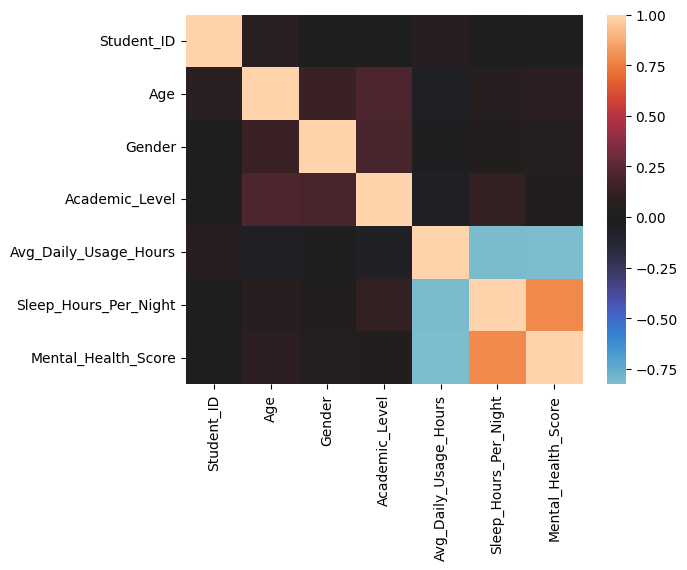

In [83]:
#блок с тепловой картой 

numeric_cols = df_transformed.select_dtypes(include=['int64', 'float64', 'bool']).columns.to_list()

print(numeric_cols)

sns.heatmap(df_transformed[numeric_cols].corr(), center=0)

In [84]:
#Блок с обучением модели

# Признаки (X) и целевая переменная (y)

X = data.drop(['Overall_Impact', 'Student_ID'], axis=1)
y = data['Overall_Impact']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6769
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [85]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),   # 2 скрытых слоя
    activation='relu',
    max_iter=1000,
    random_state=6769
)

# Обучаем
model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",6769


In [86]:
# Предсказание
y_pred = model.predict(X_test)

In [87]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='weighted', zero_division=0))

Accuracy: 0.9560117302052786
Precision: 0.9562096121085789
Recall: 0.9560117302052786
F1-score: 0.9545262927000513


In [88]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[178   1   0]
 [  5  46   7]
 [  1   1 102]]
